In [1]:
from data_prep import *
from sklearn.preprocessing import scale
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [18]:
X, y, subj_idx = load_data('data')
nclasses = len(np.unique(y))

In [12]:
def train_model(X, y, groups) -> (float, float, float, np.ndarry):
    '''Given prepared X, y, and group vectors, train n models with LOSO CV. Return average accuracy, precision, recall, and confusion matrix'''
    # initialize
    n_subjs = 0
    acc_sum = 0
    prec_sum = 0
    rec_sum = 0
    confusion = np.zeros((nclasses, nclasses))

    # one subject's data (as identified by index of subjects to rows) will be left out for testing each model
    loso = LeaveOneGroupOut()
    for train, test in loso.split(X, y, groups = subj_idx):
        # progress bar
        if n_subjs % 5 == 0:
            print(f'Computing LOSO Fold {n_subjs}...')

        # split
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]
        
        # train and predict
        # why random forest: minimal overfitting, nonlinear, robust to outliers, faster and easier than svm
        model = RandomForestClassifier(random_state=67).fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # running sum for average scores
        acc_sum += accuracy_score(y_test, y_pred)
        prec_sum += precision_score(y_test, y_pred, average='micro')
        rec_sum += recall_score(y_test, y_pred, average='micro')
        confusion += confusion_matrix(y_test, y_pred)
        n_subjs += 1
    
    return (acc_sum/n_subjs, prec_sum/n_subjs, rec_sum/n_subjs, confusion/n_subjs)

In [6]:
# ORIGINAL DATA
n_subjs = 0
acc_sum = 0
prec_sum = 0
rec_sum = 0
confusion = np.zeros((nclasses, nclasses))

for train, test in loso.split(X, y, groups = subj_idx):
    if n_subjs % 5 == 0:
        print(f'Computing LOSO Fold {n_subjs}...')

    X_train, X_test = X[train], X[test]
    y_train, y_test = y[train], y[test]
    
    # why random forest: minimal overfitting, nonlinear, robust to outliers, faster and easier than svm
    model = RandomForestClassifier(random_state=67).fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc_sum += accuracy_score(y_test, y_pred)
    prec_sum += precision_score(y_test, y_pred, average='micro')
    rec_sum += recall_score(y_test, y_pred, average='micro')
    confusion += confusion_matrix(y_test, y_pred)
    n_subjs += 1

    # print(f'CROSS FOLD {i}' + ('=' * 15))
    # print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
    # print(f'Precision: {precision_score(y_test, y_pred, average='macro')}')
    # print(f'Recall: {recall_score(y_test, y_pred, average='macro')}')
    # ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    # plt.show()

    # with open('model_results.txt', 'a') as f:
    #     f.write(f'\n===== CROSS FOLD {i}' + ('=' * 10))
    #     f.write(f'\nAccuracy: {accuracy_score(y_test, y_pred)}')
    #     f.write(f'\nPrecision: {precision_score(y_test, y_pred, average='macro')}')
    #     f.write(f'\nRecall: {recall_score(y_test, y_pred, average='macro')}')
    #     for r in confusion_matrix(y_test, y_pred):
    #         f.write('\n')
    #         for c in r:
    #             f.write(f'[{c:^5}]')

Computing LOSO Fold 0...
Computing LOSO Fold 5...
Computing LOSO Fold 10...
Computing LOSO Fold 15...
Computing LOSO Fold 20...
Computing LOSO Fold 25...
Computing LOSO Fold 30...
Computing LOSO Fold 35...
Computing LOSO Fold 40...
Computing LOSO Fold 45...
Computing LOSO Fold 50...
Computing LOSO Fold 55...
Computing LOSO Fold 60...
Computing LOSO Fold 65...
Computing LOSO Fold 70...
Computing LOSO Fold 75...
Computing LOSO Fold 80...
Computing LOSO Fold 85...
Computing LOSO Fold 90...
Computing LOSO Fold 95...
Computing LOSO Fold 100...


In [15]:
with open('experiment_results.txt', 'w') as f:
    f.write('==== EXPERIMENT 1: UNMODIFIED DATA ====')
    f.write(f'\nAccuracy: {acc_sum / n_subjs}')
    f.write(f'\nPrecision: {prec_sum / n_subjs}')
    f.write(f'\nRecall: {rec_sum / n_subjs}')
    confusion_avg = confusion / n_subjs
    for r in confusion:
        f.write('\n')
        for c in r:
            f.write(f'[{c:^8}]')

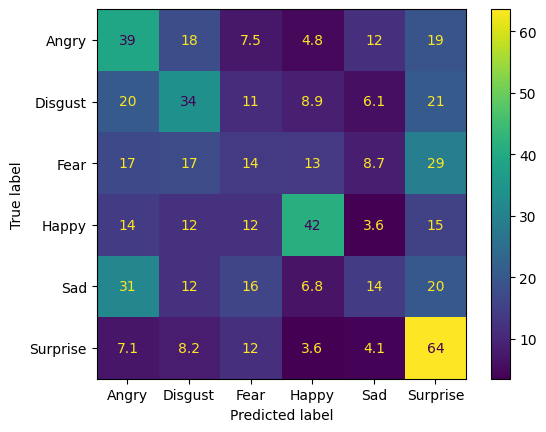

In [21]:
disp = ConfusionMatrixDisplay(confusion_avg, display_labels=np.unique(y))
disp.plot()
plt.savefig('experiment1_confusion.jpg')
plt.show()

In [46]:
confusion = np.array([
    [3947.0, 1803.0, 758.0, 489.0, 1186.0, 1941.0],
    [2067.0, 3394.0, 1122.0, 900.0, 614.0, 2074.0],
    [1699.0, 1755.0, 1391.0, 1363.0, 880.0, 2956.0],
    [1416.0, 1212.0, 1230.0, 4194.0, 366.0, 1555.0],
    [3173.0, 1212.0, 1630.0, 690.0, 1409.0, 2028.0],
    [718.0, 825.0, 1209.0, 359.0, 415.0, 6422.0]
])
results = {'accuracy': 0.34468760203408133, 'precision': 0.34468760203408133, 'recall': 0.34468760203408133, 'confusion_mat': confusion/100}

In [47]:
import json
def render_results(results: dict, file_suffix: str, labels: np.ndarray):
    '''
        Display results of model training  and save to JSON, plus confusion matrix graphic to jpeg file. Identify by suffix, which will be the transform code passed in, and timestamp
            results: dictionary as returned by train_models
            file_suffix: transformation code to identify experiments
            labels: emotion labels for confusion matrix
    '''
    timestamp = strftime('%m-%d-%H:%M', localtime())
    # print results
    print('-' * 64)
    header = f'Results of experiment with transform {file_suffix} ({timestamp})'
    print(f'{header:^64}\n')
    print(f'Accuracy: {results['accuracy']}')
    print(f'Precision: {results['precision']}')
    print(f'Recall: {results['recall']}')
    # confusion matrix print out
    confusion = results['confusion_mat']
    print(f'\nConfusion Matrix (True ~ Predicted, labels = {[str(l) for l in labels]})')
    for r in confusion:
        for i in r:
            print(f'[{i:^8}]', end = '')
        print()
    # render confusion matrix
    disp = ConfusionMatrixDisplay(confusion, display_labels=labels)
    disp.plot()
    plt.savefig(f'results/confusionMatrix_{file_suffix}_{timestamp}.jpg') # save to file
    plt.show()

    # write json results
    results['confusion_mat'] = confusion.tolist()
    with open(f'results/results_{file_suffix}_{timestamp}.txt', 'w', encoding='utf-8') as f:
        json.dump(results, f, indent = 4)

----------------------------------------------------------------
      Results of experiment with transform o (03-03-13:50)      

Accuracy: 0.34468760203408133
Precision: 0.34468760203408133
Recall: 0.34468760203408133

Confusion Matrix (True ~ Predicted, labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise'])
[ 39.47  ][ 18.03  ][  7.58  ][  4.89  ][ 11.86  ][ 19.41  ]
[ 20.67  ][ 33.94  ][ 11.22  ][  9.0   ][  6.14  ][ 20.74  ]
[ 16.99  ][ 17.55  ][ 13.91  ][ 13.63  ][  8.8   ][ 29.56  ]
[ 14.16  ][ 12.12  ][  12.3  ][ 41.94  ][  3.66  ][ 15.55  ]
[ 31.73  ][ 12.12  ][  16.3  ][  6.9   ][ 14.09  ][ 20.28  ]
[  7.18  ][  8.25  ][ 12.09  ][  3.59  ][  4.15  ][ 64.22  ]


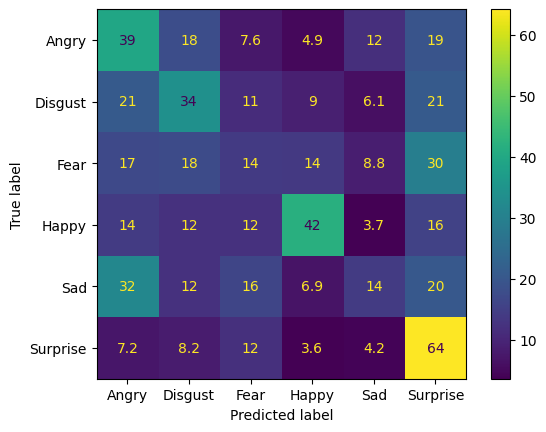

In [49]:
render_results(results, 'o', np.unique(y))

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions
# https://medium.com/@christophermiguelaguirre/defining-a-function-to-create-a-confusion-matrix-from-k-fold-cross-validation-results-8766b81984b0
